# Assignment 5: Support Vector Machine

**Name:** Soumik Bhattacharyya (MDE2026005)   
**Course:** ADA  
**Assignment:** 5

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)
import time

np.random.seed(42)

## Part A: Dataset Understanding and Preprocessing

### A1. Dataset Exploration

Load the Breast Cancer Wisconsin Diagnostic dataset and report the dataset dimensions, feature names, target classes, and class distribution.

Number of samples: 569
Number of features: 30

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target classes:
['malignant' 'benign']

Class distribution:
Class 0 (malignant): 212 samples (37.26%)
Class 1 (benign): 357 samples (62.74%)


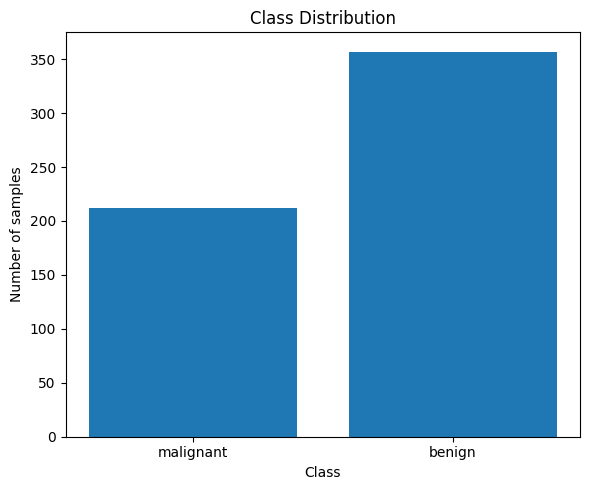

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature names:")
print(data.feature_names)

print("\nTarget classes:")
print(data.target_names)

class_counts = np.bincount(y)
class_percentages = class_counts / len(y) * 100

print("\nClass distribution:")
for class_value, count, percentage in zip(
    range(len(class_counts)),
    class_counts,
    class_percentages
):
    print(
        f"Class {class_value} ({data.target_names[class_value]}): "
        f"{count} samples ({percentage:.2f}%)"
    )

plt.figure(figsize=(6, 5))
plt.bar(data.target_names, class_counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

### A2. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


### A3. Standardization


**Why scaling is important for SVM:** SVMs depend on distances and the geometry of the feature space. Features with larger numerical scales can otherwise dominate the optimization and kernel calculations. Standardization puts features on comparable scales.

In [4]:
print("Before scaling:")
print("Training mean :", X_train.mean(axis=0))
print("Training standard deviation:", X_train.std(axis=0))
print("\n")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("After Scaling: ")
print("Training mean :", X_train_scaled.mean(axis=0))
print("Training standard deviation:", X_train_scaled.std(axis=0))

Before scaling:
Training mean : [1.40672132e+01 1.92473626e+01 9.15574066e+01 6.48541099e+02
 9.61674286e-02 1.03868901e-01 8.91933224e-02 4.83439516e-02
 1.80618022e-01 6.28197802e-02 3.98971868e-01 1.21872923e+00
 2.82255011e+00 3.92437473e+01 7.08365714e-03 2.55379802e-02
 3.25524826e-02 1.16727824e-02 2.07788308e-02 3.79728374e-03
 1.61772264e+01 2.56472967e+01 1.06625297e+02 8.69026593e+02
 1.32328923e-01 2.54328571e-01 2.76578191e-01 1.13904332e-01
 2.90865275e-01 8.39446154e-02]
Training standard deviation: [3.49553212e+00 4.40044714e+00 2.41226787e+01 3.44565295e+02
 1.34429172e-02 5.34628148e-02 8.16570636e-02 3.88817548e-02
 2.80435443e-02 7.15154679e-03 2.67530622e-01 5.70894390e-01
 1.97130469e+00 4.17172778e+01 3.13190654e-03 1.84464287e-02
 3.23346642e-02 6.28280287e-03 8.75425038e-03 2.77706609e-03
 4.76477484e+00 6.21862498e+00 3.31585545e+01 5.52318965e+02
 2.25254161e-02 1.59706175e-01 2.15699142e-01 6.67105163e-02
 6.45533961e-02 1.83874818e-02]


After Scaling: 
Tra

## Part B — Maximum-Margin Hyperplane

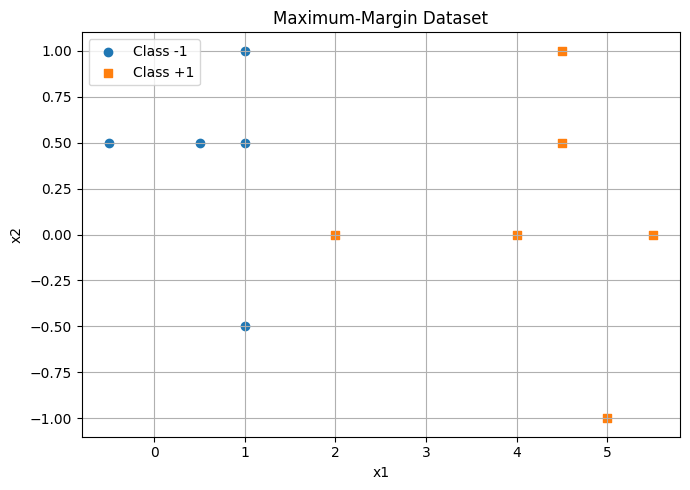

In [5]:
X_margin = np.array([
    [1, 0.5],
    [1, 1],
    [1, -0.5],
    [-0.5, 0.5],
    [0.5, 0.5],
    [2, 0],
    [4, 0],
    [4.5, 1],
    [4.5, 0.5],
    [5, -1],
    [5.5, 0]
], dtype=float)

y_margin = np.array([
    -1, -1, -1, -1, -1,
     1,  1,  1,  1,  1,  1
])

plt.figure(figsize=(7, 5))
plt.scatter(
    X_margin[y_margin == -1, 0],
    X_margin[y_margin == -1, 1],
    marker="o",
    label="Class -1"
)
plt.scatter(
    X_margin[y_margin == 1, 0],
    X_margin[y_margin == 1, 1],
    marker="s",
    label="Class +1"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Maximum-Margin Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### B2. Train a Linear SVM and Obtain the Decision Boundary

In [6]:
margin_svm = SVC(kernel="linear", C=1e6)
margin_svm.fit(X_margin, y_margin)

w = margin_svm.coef_[0]
b = margin_svm.intercept_[0]

print("w =", w)
print("b =", b)
print(f"Decision boundary: {w[0]:.6f} x1 + {w[1]:.6f} x2 + {b:.6f} = 0")

w = [ 1.9996e+00 -4.0000e-04]
b = -2.9994
Decision boundary: 1.999600 x1 + -0.000400 x2 + -2.999400 = 0


### B3. Distance of Every Point from the Hyperplane

In [7]:
distances = np.abs(X_margin @ w + b) / np.linalg.norm(w)
distances = distances.round(2)

distance_table = pd.DataFrame({
    "x1": X_margin[:, 0],
    "x2": X_margin[:, 1],
    "Class": y_margin,
    "Distance": distances
})

print(distance_table.to_string(index=False))

closest_indices = np.where(
    np.isclose(distances, distances.min(), rtol=1e-5, atol=1e-8)
)[0]

print("\nClosest point indices:", closest_indices)
print("Closest points:")
print(X_margin[closest_indices])

  x1   x2  Class  Distance
 1.0  0.5     -1       0.5
 1.0  1.0     -1       0.5
 1.0 -0.5     -1       0.5
-0.5  0.5     -1       2.0
 0.5  0.5     -1       1.0
 2.0  0.0      1       0.5
 4.0  0.0      1       2.5
 4.5  1.0      1       3.0
 4.5  0.5      1       3.0
 5.0 -1.0      1       3.5
 5.5  0.0      1       4.0

Closest point indices: [0 1 2 5]
Closest points:
[[ 1.   0.5]
 [ 1.   1. ]
 [ 1.  -0.5]
 [ 2.   0. ]]


### B4. Complete Margin and Support Vectors

Support vectors are the training points that lie on the margin boundaries for the hard-margin solution. They determine the position of the maximum-margin decision boundary.

||w|| = 1.9996000400080012
Complete margin = 1.0002000199959975

Support-vector indices: [1 2 5]
Support vectors:
[[ 1.   1. ]
 [ 1.  -0.5]
 [ 2.   0. ]]


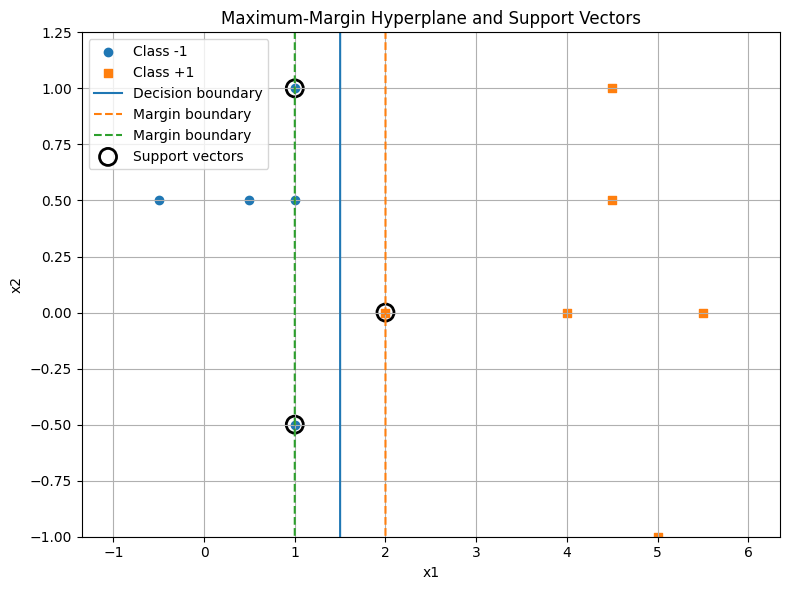

In [11]:
complete_margin = 2 / np.linalg.norm(w)

support_indices = margin_svm.support_
support_vectors = margin_svm.support_vectors_

print("||w|| =", np.linalg.norm(w))
print("Complete margin =", complete_margin)

print("\nSupport-vector indices:", support_indices)
print("Support vectors:")
print(support_vectors)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_margin[y_margin == -1, 0],
    X_margin[y_margin == -1, 1],
    marker="o",
    label="Class -1"
)
plt.scatter(
    X_margin[y_margin == 1, 0],
    X_margin[y_margin == 1, 1],
    marker="s",
    label="Class +1"
)

x_plot = np.linspace(
    X_margin[:, 0].min() - 0.5,
    X_margin[:, 0].max() + 0.5,
    300
)

decision_y = -(w[0] * x_plot + b) / w[1]
margin_y_positive = -(w[0] * x_plot + b - 1) / w[1]
margin_y_negative = -(w[0] * x_plot + b + 1) / w[1]

plt.plot(x_plot, decision_y, label="Decision boundary")
plt.plot(x_plot, margin_y_positive, "--", label="Margin boundary")
plt.plot(x_plot, margin_y_negative, "--", label="Margin boundary")

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support vectors"
)

plt.ylim(-1.0, 1.25)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Maximum-Margin Hyperplane and Support Vectors")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Part C — SVM Formulation and Hinge Loss

### C1. Why does minimizing \(\|w\|^2\) maximize the margin?

The distance between the two margin hyperplanes is \(2/\|w\|\). Therefore, minimizing \(\|w\|^2\) minimizes the denominator and increases the distance between the margin boundaries, producing the maximum-margin separator.

### C2. Hinge Loss and Soft-Margin Objective

In [12]:
def hinge_loss(y_true, scores):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    return np.maximum(0, 1 - y_true * scores)


def soft_margin_objective(w, b, X, y, lambda_value=0.01):
    scores = X @ w + b
    return (
        lambda_value * np.sum(w ** 2)
        + np.sum(hinge_loss(y, scores))
    )


margin_scores = X_margin @ w + b
point_hinge_losses = hinge_loss(y_margin, margin_scores)

print("Hinge loss for each point:")
print(point_hinge_losses)

print("\nSoft-margin objective:")
print(
    soft_margin_objective(
        w,
        b,
        X_margin,
        y_margin,
        lambda_value=0.01
    )
)

Hinge loss for each point:
[4.4408921e-16 0.0000000e+00 4.0000000e-04 0.0000000e+00 0.0000000e+00
 2.0000000e-04 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00]

Soft-margin objective:
0.040584003199999934


### C3. Margin Status of Selected Points

In [13]:
selected_indices = [0, 2, 5, 9]

selected_scores = X_margin[selected_indices] @ w + b
selected_functional_margins = (
    y_margin[selected_indices] * selected_scores
)

for index, functional_margin in zip(
    selected_indices,
    selected_functional_margins
):
    if functional_margin > 1:
        status = "Outside the margin"
    elif np.isclose(functional_margin, 1, atol=1e-6):
        status = "On the margin"
    else:
        status = "Inside the margin"

    if functional_margin <= 0:
        status = "Misclassified"

    print(
        f"Point {index}: "
        f"y_i(w^T x_i + b) = {functional_margin:.6f} -> {status}"
    )

Point 0: y_i(w^T x_i + b) = 1.000000 -> On the margin
Point 2: y_i(w^T x_i + b) = 0.999600 -> Inside the margin
Point 5: y_i(w^T x_i + b) = 0.999800 -> Inside the margin
Point 9: y_i(w^T x_i + b) = 6.999000 -> Outside the margin


## Part D — Support Vector Analysis

### Identify the support vectors

In [14]:
linear_svm = SVC(kernel="linear", C=1)
linear_svm.fit(X_train_scaled, y_train)

n_support_vectors = len(linear_svm.support_)
support_vector_percentage = (
    n_support_vectors / len(X_train_scaled) * 100
)

print("Number of support vectors:", n_support_vectors)
print("Support-vector percentage:", f"{support_vector_percentage:.2f}%")

Number of support vectors: 32
Support-vector percentage: 7.03%


### D2. Why do points far from the decision boundary have less influence?

In SVM optimization, points that satisfy the margin constraint with room to spare have zero hinge-loss contribution. The boundary is therefore determined primarily by points near the margin, including the support vectors.

### D3. Effect of C

In [15]:
C_values = [0.01, 0.1, 1, 10, 100]
C_results = []

for C in C_values:
    model = SVC(kernel="linear", C=C)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    n_sv = len(model.support_)
    sv_percentage = n_sv / len(X_train_scaled) * 100

    C_results.append({
        "C": C,
        "Support Vectors": n_sv,
        "Support Vector %": sv_percentage,
        "Test Accuracy": accuracy
    })

C_results_df = pd.DataFrame(C_results)

print(C_results_df.to_string(index=False))

     C  Support Vectors  Support Vector %  Test Accuracy
  0.01               99         21.758242       0.964912
  0.10               51         11.208791       0.982456
  1.00               32          7.032967       0.973684
 10.00               26          5.714286       0.982456
100.00               26          5.714286       0.973684


## Part E — Kernel SVM

Train SVM models using linear, polynomial, RBF, and sigmoid kernels on the same training/testing split.

The kernel trick allows an SVM to compute similarities corresponding to a higher-dimensional feature space without explicitly constructing that space. This permits nonlinear decision boundaries in the original feature space.

In [16]:
kernel_models = {
    "Linear": SVC(kernel="linear", C=1),
    "Polynomial": SVC(kernel="poly", C=1, degree=3),
    "RBF": SVC(kernel="rbf", C=1),
    "Sigmoid": SVC(kernel="sigmoid", C=1)
}

kernel_results = []

for name, model in kernel_models.items():
    start_time = time.perf_counter()

    model.fit(X_train_scaled, y_train)

    training_time = time.perf_counter() - start_time

    train_predictions = model.predict(X_train_scaled)
    test_predictions = model.predict(X_test_scaled)

    kernel_results.append({
        "Kernel": name,
        "Train Acc.": accuracy_score(y_train, train_predictions),
        "Test Acc.": accuracy_score(y_test, test_predictions),
        "No. SVs": len(model.support_),
        "Time": training_time
    })

kernel_results_df = pd.DataFrame(kernel_results)

print(kernel_results_df.to_string(index=False))

    Kernel  Train Acc.  Test Acc.  No. SVs     Time
    Linear    0.991209   0.973684       32 0.004467
Polynomial    0.916484   0.912281      145 0.004953
       RBF    0.982418   0.982456       97 0.004223
   Sigmoid    0.956044   0.929825       66 0.003982


## Part F — Hyperparameter Analysis

### F1. C–γ Grid Search

     C  gamma  Test Accuracy
  0.01  0.001       0.631579
  0.01  0.010       0.631579
  0.01  0.100       0.631579
  0.01  1.000       0.631579
  0.10  0.001       0.798246
  0.10  0.010       0.956140
  0.10  0.100       0.947368
  0.10  1.000       0.631579
  1.00  0.001       0.956140
  1.00  0.010       0.982456
  1.00  0.100       0.956140
  1.00  1.000       0.631579
 10.00  0.001       0.982456
 10.00  0.010       0.982456
 10.00  0.100       0.947368
 10.00  1.000       0.631579
100.00  0.001       0.982456
100.00  0.010       0.964912
100.00  0.100       0.938596
100.00  1.000       0.631579


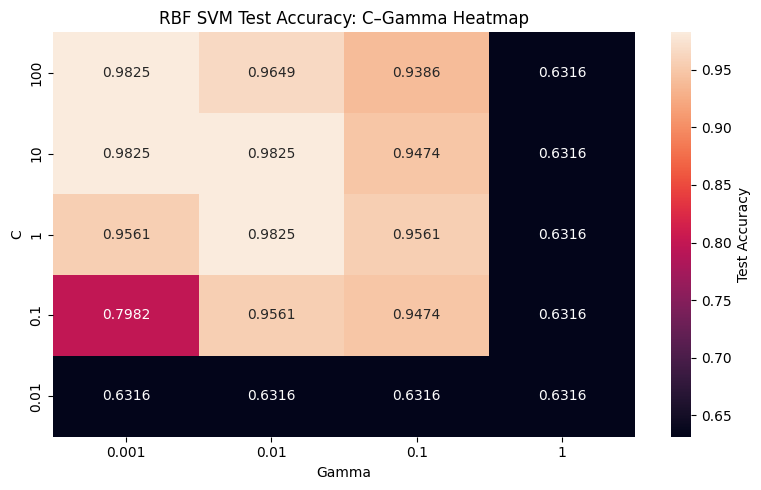

In [25]:
C_grid = [0.01, 0.1, 1, 10, 100]
gamma_grid = [0.001, 0.01, 0.1, 1]

f_results = []

for C in C_grid:
    for gamma in gamma_grid:
        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma
        )

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, predictions)

        f_results.append({
            "C": C,
            "gamma": gamma,
            "Test Accuracy": accuracy
        })

f_results_df = pd.DataFrame(f_results)

print(f_results_df.to_string(index=False))

accuracy_matrix = f_results_df.pivot(
    index="C",
    columns="gamma",
    values="Test Accuracy"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    accuracy_matrix, 
    annot=True,              
    fmt=".4f",               
    xticklabels=gamma_grid, 
    yticklabels=C_grid,
    cbar_kws={'label': 'Test Accuracy'}
)

plt.xlabel("Gamma")
plt.ylabel("C")
plt.title("RBF SVM Test Accuracy: C–Gamma Heatmap")

# Optional: Invert the y-axis if you want the lower values at the bottom 
# (Seaborn defaults to 'upper' origin, unlike your original 'lower')
plt.gca().invert_yaxis() 

plt.tight_layout()
plt.show()

### F2. Hyperparameter Discussion

- Increasing **C** places more emphasis on training points that violate the margin, generally allowing less training error while potentially reducing regularization.
- Increasing **γ** makes the RBF kernel more localized, so individual training points have influence over a smaller region.
- Very small values of **C** or **γ** can produce underfitting.
- Very large values of **C** or **γ** can produce more complex boundaries and may lead to overfitting.

The numerical grid-search results below are used to identify the highest test accuracy combination.

In [18]:
best_grid_row = f_results_df.loc[
    f_results_df["Test Accuracy"].idxmax()
]

best_C = best_grid_row["C"]
best_gamma = best_grid_row["gamma"]

print("Highest test accuracy:", best_grid_row["Test Accuracy"])
print("Selected C:", best_C)
print("Selected gamma:", best_gamma)

Highest test accuracy: 0.9824561403508771
Selected C: 1.0
Selected gamma: 0.01


## Part G — Comprehensive Classification Assessment

Use the selected RBF model from Part F and calculate all requested confusion-matrix-based metrics.

For this dataset, class 1 is treated as the positive class and class 0 as the negative class.

In [19]:
best_rbf_model = SVC(
    kernel="rbf",
    C=best_C,
    gamma=best_gamma
)
best_rbf_model.fit(X_train_scaled, y_train)

best_predictions = best_rbf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, best_predictions)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

accuracy = (tp + tn) / (tp + tn + fp + fn)
error_rate = 1 - accuracy

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

precision = tp / (tp + fp)
npv = tn / (tn + fn)

f1 = (
    2 * precision * sensitivity
    / (precision + sensitivity)
)

mcc_denominator = np.sqrt(
    (tp + fp)
    * (tp + fn)
    * (tn + fp)
    * (tn + fn)
)

mcc = (
    (tp * tn - fp * fn) / mcc_denominator
    if mcc_denominator != 0
    else 0.0
)

geometric_mean = np.sqrt(sensitivity * specificity)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Error Rate",
        "Sensitivity / Recall / TPR",
        "Specificity / TNR",
        "Precision",
        "F1-score",
        "FPR",
        "FNR",
        "NPV",
        "MCC",
        "Geometric Mean"
    ],
    "Value": [
        accuracy,
        error_rate,
        sensitivity,
        specificity,
        precision,
        f1,
        fpr,
        fnr,
        npv,
        mcc,
        geometric_mean
    ]
})

print("\nClassification Metrics:")
print(metrics_table.to_string(index=False))

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Metrics:
                    Metric    Value
                  Accuracy 0.982456
                Error Rate 0.017544
Sensitivity / Recall / TPR 0.986111
         Specificity / TNR 0.976190
                 Precision 0.986111
                  F1-score 0.986111
                       FPR 0.023810
                       FNR 0.013889
                       NPV 0.976190
                       MCC 0.962302
            Geometric Mean 0.981138


### G1–G7. Metric Interpretation

- **MCC = 1:** perfect agreement between predictions and true classes.
- **MCC = 0:** no better than the reference level represented by the MCC measure.
- **MCC = -1:** complete disagreement between predictions and true classes.
- **Geometric Mean:** combines sensitivity and specificity. It is useful when performance on both classes matters because a low value for either class-specific measure lowers the overall geometric mean.

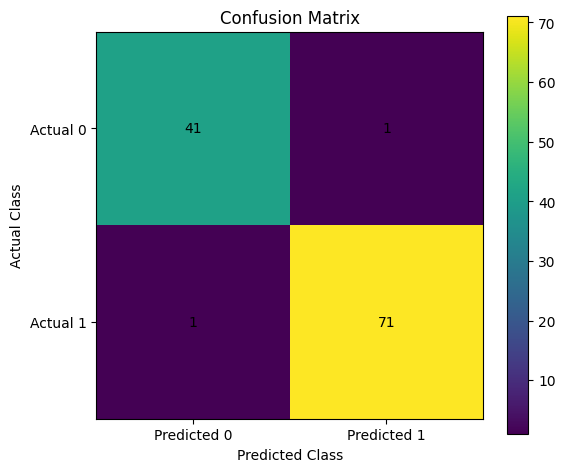

In [20]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## Part H — ROC Curve and AUC

Obtain continuous decision scores for all four kernels, plot TPR against FPR, calculate ROC-AUC, and compare the model with the highest accuracy against the model with the highest ROC-AUC.

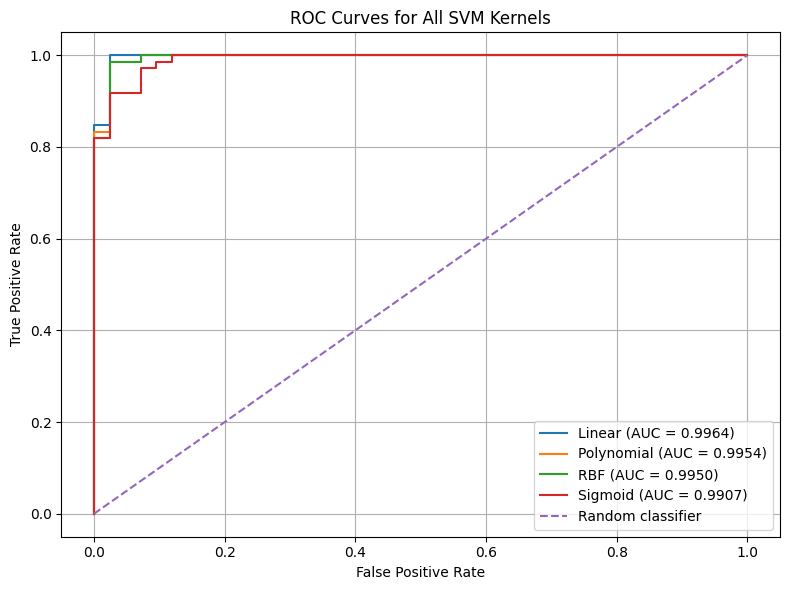

    Kernel  ROC-AUC
    Linear 0.996362
Polynomial 0.995370
       RBF 0.995040
   Sigmoid 0.990741


In [21]:
roc_results = {}

plt.figure(figsize=(8, 6))

for name, model in kernel_models.items():
    # Use the same already-fitted kernel models from Part E.
    decision_scores = model.decision_function(X_test_scaled)

    fpr_values, tpr_values, _ = roc_curve(
        y_test,
        decision_scores
    )

    roc_auc = roc_auc_score(
        y_test,
        decision_scores
    )

    roc_results[name] = {
        "FPR": fpr_values,
        "TPR": tpr_values,
        "ROC-AUC": roc_auc
    }

    plt.plot(
        fpr_values,
        tpr_values,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All SVM Kernels")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

roc_auc_table = pd.DataFrame({
    "Kernel": list(roc_results.keys()),
    "ROC-AUC": [
        roc_results[name]["ROC-AUC"]
        for name in roc_results
    ]
})

print(roc_auc_table.to_string(index=False))

### H1. ROC-AUC Comparison

In [22]:
accuracy_table = kernel_results_df[
    ["Kernel", "Test Acc."]
].copy()

roc_comparison = accuracy_table.merge(
    roc_auc_table,
    on="Kernel"
)

highest_accuracy_kernel = roc_comparison.loc[
    roc_comparison["Test Acc."].idxmax(),
    "Kernel"
]

highest_auc_kernel = roc_comparison.loc[
    roc_comparison["ROC-AUC"].idxmax(),
    "Kernel"
]

print(roc_comparison.to_string(index=False))

print("\nKernel with highest accuracy:", highest_accuracy_kernel)
print("Kernel with highest ROC-AUC:", highest_auc_kernel)

if highest_accuracy_kernel == highest_auc_kernel:
    print("The model with the highest accuracy also has the highest ROC-AUC.")
else:
    print("The model with the highest accuracy does not have the highest ROC-AUC.")

    Kernel  Test Acc.  ROC-AUC
    Linear   0.973684 0.996362
Polynomial   0.912281 0.995370
       RBF   0.982456 0.995040
   Sigmoid   0.929825 0.990741

Kernel with highest accuracy: RBF
Kernel with highest ROC-AUC: Linear
The model with the highest accuracy does not have the highest ROC-AUC.


## Part I — Precision–Recall Curve and PR-AUC

The Precision–Recall curves compare precision against recall for all four SVM kernels. PR-AUC summarizes the overall precision–recall performance.

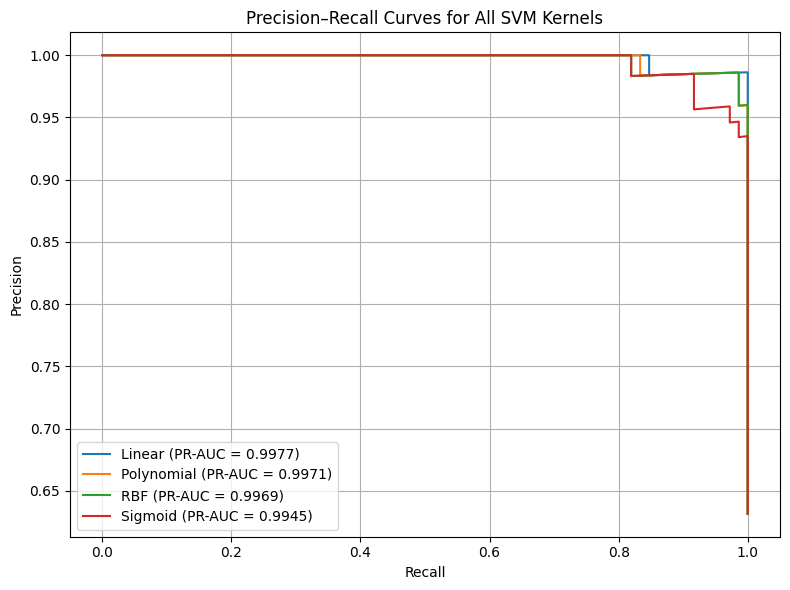

    Kernel   PR-AUC
    Linear 0.997732
Polynomial 0.997138
       RBF 0.996908
   Sigmoid 0.994466


In [26]:
pr_results = {}

plt.figure(figsize=(8, 6))

for name, model in kernel_models.items():
    decision_scores = model.decision_function(X_test_scaled)
    precision_values, recall_values, _ = precision_recall_curve(
        y_test, decision_scores
    )
    pr_auc = auc(recall_values, precision_values)

    pr_results[name] = {
        "Precision": precision_values,
        "Recall": recall_values,
        "PR-AUC": pr_auc
    }

    plt.plot(
        recall_values,
        precision_values,
        label=f"{name} (PR-AUC = {pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for All SVM Kernels")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

pr_auc_table = pd.DataFrame({
    "Kernel": list(pr_results.keys()),
    "PR-AUC": [pr_results[name]["PR-AUC"] for name in pr_results]
})

print(pr_auc_table.to_string(index=False))

### I1–I4. Precision–Recall Analysis

1. **Highest PR-AUC:** Linear kernel (0.9977).
2. **Highest ROC-AUC:** Linear kernel (0.9964).
3. **Are the rankings identical?** Yes for the highest-ranked kernel: Linear has the highest value for both ROC-AUC and PR-AUC.
4. **Does the highest-accuracy model also have the best PR performance?** No. The RBF kernel has the highest test accuracy (0.9825), while the Linear kernel has the highest PR-AUC (0.9977).

The small differences among the PR-AUC values show that all four kernels provide strong precision–recall performance on this test set, although their classification accuracies differ more substantially.

## Part J — Final Model Comparison

The following table combines the requested classification metrics with ROC-AUC and PR-AUC for all four kernels. The positive class is class 1 (benign), consistent with Part G.

In [28]:
final_comparison = []

for name, model in kernel_models.items():
    predictions = model.predict(X_test_scaled)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    f1 = 2 * precision * recall / (precision + recall)
    mcc_denominator = np.sqrt(
        (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    )
    mcc = (tp * tn - fp * fn) / mcc_denominator

    decision_scores = model.decision_function(X_test_scaled)
    roc_auc = roc_auc_score(y_test, decision_scores)
    precision_values, recall_values, _ = precision_recall_curve(
        y_test, decision_scores
    )
    pr_auc = auc(recall_values, precision_values)

    final_comparison.append({
        "Model": name,
        "Acc.": accuracy,
        "Recall": recall,
        "Spec.": specificity,
        "Prec.": precision,
        "F1": f1,
        "MCC": mcc,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

final_comparison_df = pd.DataFrame(final_comparison)

print(final_comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nSelected RBF hyperparameters:")
print("C =", best_C)
print("gamma =", best_gamma)
print("Support vectors =", len(best_rbf_model.support_))
print("\nSelected RBF confusion matrix:")
print(cm)

     Model   Acc.  Recall  Spec.  Prec.     F1    MCC  ROC-AUC  PR-AUC
    Linear 0.9737  0.9722 0.9762 0.9859 0.9790 0.9439   0.9964  0.9977
Polynomial 0.9123  1.0000 0.7619 0.8780 0.9351 0.8179   0.9954  0.9971
       RBF 0.9825  0.9861 0.9762 0.9861 0.9861 0.9623   0.9950  0.9969
   Sigmoid 0.9298  0.9306 0.9286 0.9571 0.9437 0.8513   0.9907  0.9945

Selected RBF hyperparameters:
C = 1.0
gamma = 0.01
Support vectors = 94

Selected RBF confusion matrix:
[[41  1]
 [ 1 71]]


### Part J — Interpretation

The selected RBF model uses **C = 1.0** and **γ = 0.01**, chosen from the tested C–γ grid because it achieves the highest test accuracy of **0.9825** (tied with the C = 10, γ = 0.001 and C = 10, γ = 0.01 combinations). It has **94 support vectors**.

For the selected RBF model, the confusion matrix is:

| | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | 41 | 1 |
| Actual 1 | 1 | 71 |

Thus, there is one false positive and one false negative on the test set.

## Part K — Final Interpretation and Model Selection

1. **Highest accuracy:** RBF (0.9825).
2. **Highest recall:** Polynomial (1.0000).
3. **Highest specificity:** Linear and RBF (0.9762 each).
4. **Highest F1-score:** RBF (0.9861).
5. **Highest MCC:** RBF (0.9623).
6. **Highest ROC-AUC:** Linear (0.9964).
7. **Highest PR-AUC:** Linear (0.9977).
8. **Smallest FNR:** Polynomial (0.0000).
9. **Does the best-accuracy model remain best under other metrics?** No. RBF has the highest accuracy, F1-score, and MCC, while Linear has the highest ROC-AUC and PR-AUC; Polynomial has the highest recall and the smallest FNR.

### 10. Model Selection for the Medical Classification Problem

**Selected SVM Model: RBF kernel with C = 1.0 and γ = 0.01.**

The RBF model is selected because, on the given test split, it provides a strong combination of the requested metrics:

- **Accuracy:** 98.25%
- **Recall / Sensitivity:** 98.61%
- **Specificity:** 97.62%
- **Precision:** 98.61%
- **F1-score:** 98.61%
- **MCC:** 0.9623
- **FNR:** 1.39%

The model therefore makes only two test-set errors: one false positive and one false negative. Linear has slightly higher ROC-AUC and PR-AUC, while Polynomial has perfect recall on this particular test set but lower specificity and accuracy. Therefore, the RBF model gives the most balanced set of the main classification metrics used here.